In [1]:
import yaml
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
# Get gene trait associations
RAP_DIR = 'project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results'

# ASSOC_FILE = 'loftee_mac20_associations_bh_corrected.parquet'
# ASSOC_FILE = 'regenie_127phenotypes_lofteeHC_mac20_EUR.parquet'
ASSOC_FILE = 'regenie_127phenotypes_lofteeHC_mac20_EUR_miss20per.parquet'

LOCAL_DIR = '/home/dnanexus/data_dir/'

!dx download {RAP_DIR}/{ASSOC_FILE} -o {LOCAL_DIR}

gene_trait_df = (
    pl.read_parquet(f'{LOCAL_DIR}/{ASSOC_FILE}')
    .filter(pl.col('pval_fdr')<=0.05)
    .select(['region', 'phenotype', 'pval_fdr'])
)

CORR_FILE = 'regenie_127phenotypes_mac20_lofteeHC_EUR_correlations.parquet'
!dx download {RAP_DIR}/{CORR_FILE} -o {LOCAL_DIR}

loftee_corrs = (
    pl.read_parquet(f'{LOCAL_DIR}/{CORR_FILE}')
    .with_columns(
        loftee_corr = pl.col('correlation'),
        loftee_corr_abs = pl.col('correlation').abs(),
        loftee_corr_dir = pl.col('correlation')/pl.col('correlation').abs(),
    )
    .select(['region', 'phenotype', 'loftee_corr', 'loftee_corr_abs', 'loftee_corr_dir']) 
)

gene_trait_df = (
    gene_trait_df
    .join(loftee_corrs, on=['region', 'phenotype'], how='inner')
    .drop_nans()
    .sort('loftee_corr_abs', descending=True)
    .unique(subset=["region"], keep="first", maintain_order=True)
)
gene_trait_df

Error: path "/home/dnanexus/data_dir/regenie_127phenotypes_lofteeHC_mac20_EUR_
miss20per.parquet" already exists but -f/--overwrite was not set
Error: path "/home/dnanexus/data_dir/regenie_127phenotypes_mac20_lofteeHC_EUR_
correlations.parquet" already exists but -f/--overwrite was not set


region,phenotype,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir
str,str,f64,f64,f64,f64
"""ENSG00000244734""","""mean_corpuscular_haemoglobin_i…",5.8426e-107,-0.414609,0.414609,-1.0
"""ENSG00000188536""","""mean_corpuscular_haemoglobin_i…",4.2593e-22,-0.366514,0.366514,-1.0
"""ENSG00000101439""","""cystatin_c_int""",9.0570e-172,-0.364046,0.364046,-1.0
"""ENSG00000149948""","""standing_height_int""",0.035047,-0.302164,0.302164,-1.0
"""ENSG00000205846""","""aspartate_aminotransferase_int""",0.049103,0.298817,0.298817,1.0
…,…,…,…,…,…
"""ENSG00000104408""","""mean_corpuscular_volume_int""",0.003124,-0.005248,0.005248,-1.0
"""ENSG00000162992""","""glycated_haemoglobin_hba1c_int""",0.000525,0.004895,0.004895,1.0
"""ENSG00000134030""","""leg_fat_percentage_right_int""",0.028495,0.003606,0.003606,1.0


In [3]:
# Configuration and paths
mac = 20
pheno_list_type = None

# Select which experimental assay to analyze (set to None to include all)
# Options: 'scaled_fitness', 'proteingym_DMS_score', 'marsh_DMS_score', or None
selected_exp_assay = 'scaled_fitness'  # aPCA only
# selected_exp_assay = 'proteingym_DMS_score'
# selected_exp_assay = 'marsh_DMS_score'
# selected_exp_assay = None  # All experimental assays

# Load phenotype configuration
pheno_config_path = "/home/dnanexus/ukbgym/phenotype_config.yaml"
with open(pheno_config_path) as f:
    pheno_config = yaml.safe_load(f)

if pheno_list_type is not None:
    pheno_list = pheno_config[pheno_list_type]

# Load annotation configuration
config_path = "/home/dnanexus/ukbgym/config_expAssays.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

# Filter to selected experimental assay if specified
if selected_exp_assay is not None:
    anno_config_df = anno_config_df.filter(
        (pl.col('category') != 'exp_assays') | (pl.col('annotation') == selected_exp_assay)
    )
    print(f"Selected experimental assay: {selected_exp_assay}")

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

Selected experimental assay: scaled_fitness


category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""exp_assays""","""scaled_fitness""","""#66BB6A""","""aPCA fitness""",1
"""missense""","""am_pathogenicity""","""#feb72d""","""AlphaMissense""",1
"""missense""","""score_pai3d""","""#feb72d""","""PrimateAI-3D""",1
"""missense""","""esmscoremissense""","""#feb72d""","""ESM1v""",-1
"""genetic_diversity""","""cadd_raw""","""#1f77b4""","""CADD Raw""",1
…,…,…,…,…
"""protein_domains""","""low_complexity_domain""","""#FF9933""","""Low Complexity Domain""",1
"""loftee_protein_domains""","""loftee_disorder""","""#E31A1C""","""Disordered Domain""",1
"""loftee_protein_domains""","""loftee_lip""","""#1E90FF""","""Linear Interacting Peptides""",1


In [4]:
LOCAL_EXP_DIR = "/home/dnanexus/data_dir/experimental_assays"
id_cols = ['ref_aa', 'aa_position', 'alt_aa', 'region']

# --- 1. aPCA (Beltran et al., Nature 2025) ---
# One fitness score per variant, 447 genes
aPCA = (
    pl.read_parquet(f"{LOCAL_EXP_DIR}/aPCA_Beltran_Nature_2025.parquet")
    .drop_nulls(subset=id_cols)
    .group_by(id_cols).agg(pl.col('scaled_fitness').mean())
)

# --- 2. ProteinGym DMS substitutions ---
# Multiple experiments per gene; average across experiments per variant
# Filter to single substitutions only (multi-mutants have null ref_aa)
proteingym = (
    pl.read_parquet(f"{LOCAL_EXP_DIR}/DMS_ProteinGym_substitutions.parquet")
    .drop_nulls(subset=id_cols)
    .group_by(id_cols).agg(pl.col('DMS_score').mean())
    .rename({'DMS_score': 'proteingym_DMS_score'})
)

# --- 3. Marsh VEP DMS ---
# Multiple assay conditions per gene; average across conditions per variant
marsh = (
    pl.read_parquet(f"{LOCAL_EXP_DIR}/DMS_Marsh_VEP.parquet")
    .drop_nulls(subset=id_cols)
    .group_by(id_cols).agg(pl.col('DMS_score').mean())
    .rename({'DMS_score': 'marsh_DMS_score'})
)

# --- Merge all exp assays into one wide dataframe ---
exp_anno_df = (
    aPCA
    .join(proteingym, on=id_cols, how='outer_coalesce')
    .join(marsh, on=id_cols, how='outer_coalesce')
)

exp_assay_columns = ['scaled_fitness', 'proteingym_DMS_score', 'marsh_DMS_score']

print(f"aPCA: {aPCA.shape[0]} variants, {aPCA['region'].n_unique()} genes")
print(f"ProteinGym: {proteingym.shape[0]} variants, {proteingym['region'].n_unique()} genes")
print(f"Marsh VEP: {marsh.shape[0]} variants, {marsh['region'].n_unique()} genes")
print(f"Merged: {exp_anno_df.shape[0]} variants, {exp_anno_df['region'].n_unique()} genes")
exp_anno_df.head()

/tmp/ipykernel_128732/323215353.py:34: DeprecationWarning: use of `how='outer_coalesce'` should be replaced with `how='full', coalesce=True`.
(Deprecated in version 0.20.29)
/tmp/ipykernel_128732/323215353.py:35: DeprecationWarning: use of `how='outer_coalesce'` should be replaced with `how='full', coalesce=True`.
(Deprecated in version 0.20.29)


aPCA: 607560 variants, 446 genes
ProteinGym: 309338 variants, 93 genes
Marsh VEP: 237992 variants, 39 genes
Merged: 954469 variants, 530 genes


ref_aa,aa_position,alt_aa,region,scaled_fitness,proteingym_DMS_score,marsh_DMS_score
str,i64,str,str,f64,f64,f64
"""S""",456,"""Q""","""ENSG00000198373""",-0.110374,null,null
"""Y""",7,"""G""","""ENSG00000262860""",null,null,null
"""R""",87,"""M""","""ENSG00000101400""",0.016826,null,null
"""E""",92,"""M""","""ENSG00000117625""",-0.681346,null,null
"""V""",404,"""H""","""ENSG00000065328""",-0.282099,null,null


In [5]:
RAP_ANNO_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/qced_maf1e-3_loftee_olink_genes_EURunrelated"
LOCAL_ANNO_DIR = "/home/dnanexus/data_dir"

ANNO_FILE = "annotations_fillna_ukbgym_with_mane.parquet"

!dx download {RAP_ANNO_DIR}/{ANNO_FILE} -o {LOCAL_ANNO_DIR}/{ANNO_FILE}
anno = pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")

# Parse amino acid coordinates and join with experimental assay data
anno = (
    anno
    .filter(
        pl.col('amino_acids').is_not_null(),
        pl.col('amino_acids').str.contains("/"),
        ~pl.col('protein_position').str.contains("-")
    )
    .with_columns(
        pl.col("amino_acids").str.split("/").list.get(0).alias("ref_aa"),
        pl.col("amino_acids").str.split("/").list.get(1).alias("alt_aa"),
        pl.col("protein_position").str.split("/").list.get(0).cast(pl.Int64).alias("aa_position")
    )
    .join(
        exp_anno_df.lazy(),
        on=['ref_aa', 'aa_position', 'alt_aa', 'region'],
        how='left'
    )
    # Keep ALL missense variants (exp assay scores will be null where unavailable)
)

# Standard variant filters
anno = (
    anno
    .filter(
        (pl.col('region').is_in(gene_trait_df['region'].unique())),
        
        # Choose VEP consequence
        (pl.col('consequence_missense_variant') == True),

        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
)

selected_categories = ['exp_assays', 'missense', 'genetic_diversity', 'conservation']

selected_annos = anno_config_df.filter(
    pl.col('category').is_in(selected_categories)
)['annotation'].to_list()

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]
selected_annos = list(set(selected_annos).intersection(set(existing_annos)))

anno = (
    anno
    .select(
        set(['id', 'region']).union(set(selected_annos))
    )
    .collect(engine='streaming')
    .drop_nulls()
)

print(f"Annotation table: {anno.shape[0]} variants, {anno['region'].n_unique()} genes")
print(f"Selected annotations: {selected_annos}")
anno

Error: path
"/home/dnanexus/data_dir/annotations_fillna_ukbgym_with_mane.parquet" already
exists but -f/--overwrite was not set


/tmp/ipykernel_128732/2255576469.py:49: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
/tmp/ipykernel_128732/2255576469.py:57: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


Annotation table: 591 variants, 21 genes
Selected annotations: ['scaled_fitness', 'cadd_raw', 'score_pai3d', 'gpn_score', 'am_pathogenicity', 'verphylop', 'esmscoremissense']


region,scaled_fitness,id,cadd_raw,score_pai3d,gpn_score,am_pathogenicity,verphylop,esmscoremissense
str,f64,str,f32,f32,f32,f32,f32,f32
"""ENSG00000110395""",-0.161084,"""chr11:119299633:C:T""",4.90701,0.807093,-8.37,0.4256,5.113,-9.071
"""ENSG00000136068""",0.1228523,"""chr3:58159661:G:C""",1.236715,0.567136,-7.42,0.1278,-0.191,-4.002
"""ENSG00000121741""",0.250296,"""chr13:20006471:G:C""",4.662489,0.603737,-9.85,0.9089,10.811,-2.822
"""ENSG00000136068""",-0.229303,"""chr3:58159608:G:A""",5.312392,0.7664,-9.3,0.4916,11.295,-6.369
"""ENSG00000141968""",0.084977,"""chr19:6854088:T:A""",4.486132,0.733332,-10.92,0.8787,4.887,-8.012
…,…,…,…,…,…,…,…,…
"""ENSG00000141968""",-0.178768,"""chr19:6836479:C:A""",3.897275,0.753869,-8.56,0.771,4.697,-6.795
"""ENSG00000162063""",-0.18363,"""chr16:2431276:G:A""",1.368145,0.300631,-0.53,0.082,1.885,-4.878
"""ENSG00000127616""",-0.349826,"""chr19:11003063:C:T""",4.977156,0.872203,-8.96,0.6396,7.518,-3.74


In [6]:
melted_anno = (
    anno.lazy()

    .select(
        set(['id', 'region']).union(set(selected_annos))
    )

    .unpivot(
        index=["id", "region"],
        on=selected_annos,
        variable_name="annotation",
        value_name="annotation_score"
    )
    .with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )
        
    # Keep variants that don't have fillna annotation
    # .join(
    #     anno_fillna_melted,
    #     on=['id', 'region', 'annotation'],
    #     how='semi'
    # )
    
    .collect(engine='streaming')
)

melted_anno

id,region,annotation,annotation_score
str,str,str,f32
"""chr11:119299633:C:T""","""ENSG00000110395""","""scaled_fitness""",-0.161084
"""chr3:58159661:G:C""","""ENSG00000136068""","""scaled_fitness""",0.122852
"""chr13:20006471:G:C""","""ENSG00000121741""","""scaled_fitness""",0.250296
"""chr3:58159608:G:A""","""ENSG00000136068""","""scaled_fitness""",-0.229303
"""chr19:6854088:T:A""","""ENSG00000141968""","""scaled_fitness""",0.084977
…,…,…,…
"""chr19:6836479:C:A""","""ENSG00000141968""","""esmscoremissense""",-6.795
"""chr16:2431276:G:A""","""ENSG00000162063""","""esmscoremissense""",-4.878
"""chr19:11003063:C:T""","""ENSG00000127616""","""esmscoremissense""",-3.74


In [7]:
RAP_APPV_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/avg_pheno_per_var"
LOCAL_APPV_DIR = "/home/dnanexus/data_dir"

APPV_FILE = "quant_pheno_loftee_mac20_EURunrelated_miss20per_appv_percentiles_small.parquet"

!dx download {RAP_APPV_DIR}/{APPV_FILE} -o {LOCAL_APPV_DIR}/{APPV_FILE}
appv = pl.scan_parquet(f"{LOCAL_APPV_DIR}/{APPV_FILE}")

# Create a lazy frame with the unique keys
anno_keys = anno.select(pl.col('id').unique()).lazy()

# Chain the filter and the much faster semi join
appv = (
    appv
    .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        pl.col('n_individuals') <= mac
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value', 'n_individuals']
    )
)

Error: path "/home/dnanexus/data_dir/quant_pheno_loftee_mac20_EURunrelated_mis
s20per_appv_percentiles_small.parquet" already exists but -f/--overwrite was
not set


In [8]:
id_region = anno.select(['id', 'region']).unique().lazy()

# Build the main lazy query plan
# Join order: appv → id_region (adds region) → gene_trait_df (filter early) → melted_anno (annotation scores)
final_lazy_plan = (
    appv
    .join(id_region, on='id', how='inner')
    .join(
        gene_trait_df[["region", "phenotype"]].lazy(),
        on=["region", "phenotype"],
        how="inner"
    )
    .join(
        melted_anno.lazy(),
        on=["id", "region"],
        how="inner"
    )
    .filter(pl.col('annotation') != 'loftee_hc')

    # Spearman: rank with "average" for proper tie handling
    .with_columns(
        pl.col(c)
        .rank("average")
        .over(["region", "phenotype", "annotation"])
        .alias(f"{c}_rank")
        for c in ['annotation_score', 'mean_pheno_value']
    )

    .group_by(["region", "phenotype", "annotation"])
    .agg(
        n_variants = pl.col("id").count(),
        correlation = pl.when(
            (pl.col("annotation_score_rank").n_unique() > 1) & 
            (pl.col("mean_pheno_value_rank").n_unique() > 1)
        )
        .then(
            pl.corr("annotation_score_rank", "mean_pheno_value_rank", propagate_nans=True)
        )
        .otherwise(None)
    )

    .select(["region", "phenotype", "annotation", "n_variants", "correlation"])
    
    .drop_nans().drop_nulls()
        
    .collect(engine='streaming')
)

# Join with beta directions and annotation directions
correlation_df = (
    final_lazy_plan
    
    .join(
        anno_config_df.drop('category').unique(), 
        on='annotation'
    )
    .join(
        gene_trait_df,
        on=['region', 'phenotype'],
    )
    .with_columns(
        corr_beta = pl.col('correlation')*pl.col('loftee_corr_dir')*pl.col('annotation_dir') 
    )
    .with_columns(
        corr_beta_rescaled = (pl.col('corr_beta')/pl.col('loftee_corr'))*pl.col('loftee_corr_dir')
    )
)

print("Final DataFrame shape:", correlation_df.shape)
correlation_df

Final DataFrame shape: (139, 14)


region,phenotype,annotation,n_variants,correlation,color,label,annotation_dir,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir,corr_beta,corr_beta_rescaled
str,str,str,u64,f64,str,str,i8,f64,f64,f64,f64,f64,f64
"""ENSG00000163554""","""reticulocyte_percentage_int""","""cadd_raw""",20,0.124812,"""#1f77b4""","""CADD Raw""",1,1.3355e-47,0.190048,0.190048,1.0,0.124812,0.65674
"""ENSG00000163554""","""reticulocyte_percentage_int""","""am_pathogenicity""",20,-0.046617,"""#feb72d""","""AlphaMissense""",1,1.3355e-47,0.190048,0.190048,1.0,-0.046617,-0.245288
"""ENSG00000163554""","""reticulocyte_percentage_int""","""esmscoremissense""",20,-0.078195,"""#feb72d""","""ESM1v""",-1,1.3355e-47,0.190048,0.190048,1.0,0.078195,0.411451
"""ENSG00000163554""","""reticulocyte_percentage_int""","""scaled_fitness""",20,-0.300752,"""#66BB6A""","""aPCA fitness""",1,1.3355e-47,0.190048,0.190048,1.0,-0.300752,-1.582505
"""ENSG00000163554""","""reticulocyte_percentage_int""","""verphylop""",20,0.034586,"""#942c80""","""Vertebrate PhyloP""",1,1.3355e-47,0.190048,0.190048,1.0,0.034586,0.181988
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000060339""","""lymphocyte_count_int""","""am_pathogenicity""",13,-0.547456,"""#feb72d""","""AlphaMissense""",1,0.008137,-0.048716,0.048716,-1.0,0.547456,11.237787
"""ENSG00000060339""","""lymphocyte_count_int""","""verphylop""",13,-0.10729,"""#942c80""","""Vertebrate PhyloP""",1,0.008137,-0.048716,0.048716,-1.0,0.10729,2.20238
"""ENSG00000060339""","""lymphocyte_count_int""","""score_pai3d""",13,-0.37139,"""#feb72d""","""PrimateAI-3D""",1,0.008137,-0.048716,0.048716,-1.0,0.37139,7.623624


In [9]:
consistent_gt = (
    correlation_df
    .drop_nulls().drop_nans()
    .group_by(['region', 'phenotype'])
    .agg(n_annotations = pl.len())
    .filter(pl.col('n_annotations') == correlation_df['annotation'].n_unique())
)

# filt_corr_df = correlation_df.filter(pl.col("n_variants") > 10)
filt_corr_df = correlation_df.filter(pl.col("n_variants") > 10)
filt_corr_df = filt_corr_df.join(consistent_gt, on=['region', 'phenotype'], how='inner')
filt_corr_df

region,phenotype,annotation,n_variants,correlation,color,label,annotation_dir,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir,corr_beta,corr_beta_rescaled,n_annotations
str,str,str,u64,f64,str,str,i8,f64,f64,f64,f64,f64,f64,u64
"""ENSG00000163554""","""reticulocyte_percentage_int""","""cadd_raw""",20,0.124812,"""#1f77b4""","""CADD Raw""",1,1.3355e-47,0.190048,0.190048,1.0,0.124812,0.65674,7
"""ENSG00000163554""","""reticulocyte_percentage_int""","""am_pathogenicity""",20,-0.046617,"""#feb72d""","""AlphaMissense""",1,1.3355e-47,0.190048,0.190048,1.0,-0.046617,-0.245288,7
"""ENSG00000163554""","""reticulocyte_percentage_int""","""esmscoremissense""",20,-0.078195,"""#feb72d""","""ESM1v""",-1,1.3355e-47,0.190048,0.190048,1.0,0.078195,0.411451,7
"""ENSG00000163554""","""reticulocyte_percentage_int""","""scaled_fitness""",20,-0.300752,"""#66BB6A""","""aPCA fitness""",1,1.3355e-47,0.190048,0.190048,1.0,-0.300752,-1.582505,7
"""ENSG00000163554""","""reticulocyte_percentage_int""","""verphylop""",20,0.034586,"""#942c80""","""Vertebrate PhyloP""",1,1.3355e-47,0.190048,0.190048,1.0,0.034586,0.181988,7
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000060339""","""lymphocyte_count_int""","""am_pathogenicity""",13,-0.547456,"""#feb72d""","""AlphaMissense""",1,0.008137,-0.048716,0.048716,-1.0,0.547456,11.237787,7
"""ENSG00000060339""","""lymphocyte_count_int""","""verphylop""",13,-0.10729,"""#942c80""","""Vertebrate PhyloP""",1,0.008137,-0.048716,0.048716,-1.0,0.10729,2.20238,7
"""ENSG00000060339""","""lymphocyte_count_int""","""score_pai3d""",13,-0.37139,"""#feb72d""","""PrimateAI-3D""",1,0.008137,-0.048716,0.048716,-1.0,0.37139,7.623624,7


In [10]:
annos_w_inconsistent_assocs = (
    filt_corr_df
    .drop_nulls().drop_nans()
    .select(['region', 'phenotype', 'annotation'])
    .group_by('annotation')
    .agg(n_associations = pl.len())
    .select('n_associations').n_unique()
) - 1

print(f"Annotations with inconsistent associations: {annos_w_inconsistent_assocs}")

# Check if the variant counts are consistent within each (region, phenotype) pair
var_inconsistent = (
    filt_corr_df
    .drop_nans()
    .drop_nulls()
    .group_by(["region", "phenotype"])
    .agg(pl.col("n_variants").n_unique().alias("n_variants_unique"))
    .filter(pl.col("n_variants_unique") > 1)
)
print(f"Inconsistent (region, phenotype) pairs: {var_inconsistent.shape[0]}")

Annotations with inconsistent associations: 0
Inconsistent (region, phenotype) pairs: 0


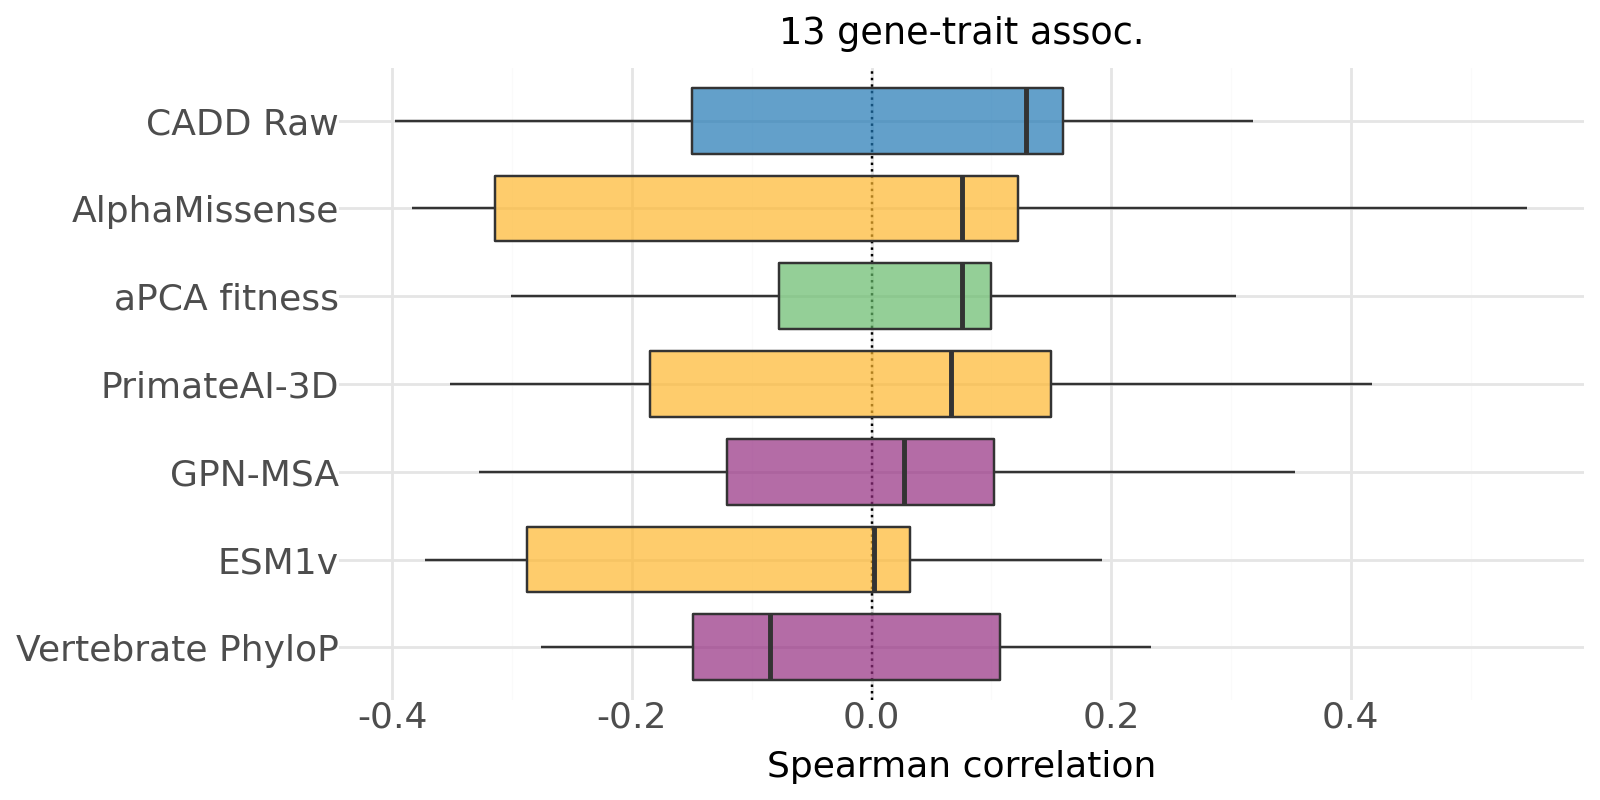

In [11]:
plotting_col = 'corr_beta'
dashed_line_value = 1 if 'rescaled' in plotting_col else 0

# Calculate medians and join back
corr_pl = (
    filt_corr_df
    .drop_nans()
    .with_columns(
        median_corr_beta = pl.col(plotting_col).median().over("annotation")
    )
)

# 2. Determine the categorical order for the labels
ordered_labels = (
    corr_pl
    .sort("median_corr_beta", descending=False)
    .select("label")
    .unique(maintain_order=True)
    .to_series()
)

# 3. Apply the ordering using pl.Enum
corr_pl = corr_pl.with_columns(pl.col("label").cast(pl.Enum(ordered_labels)))

# 4. Create the color dictionary (Polars style)
color_dict = dict(corr_pl.select("annotation", "color").unique().iter_rows())

# Plot
(
    ggplot(corr_pl, aes(x="label", y=plotting_col, fill="annotation"))
    + geom_hline(aes(yintercept=dashed_line_value), color='black', linetype='dotted')
    + geom_boxplot(alpha=0.7, outlier_shape=None)
    + theme_minimal()
    + scale_fill_manual(values=color_dict)
    + labs(
        x="",
        y="Spearman correlation",
        title=f"{corr_pl[['region', 'phenotype']].unique().shape[0]} gene-trait assoc."
    )
    + coord_flip()
    + theme(
        figure_size=(8, corr_pl['annotation'].n_unique()/2 + 0.5),
        legend_position="none",
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        plot_background=element_rect(fill="white", color="white"),
    )
)

No significant adjacent pairs found


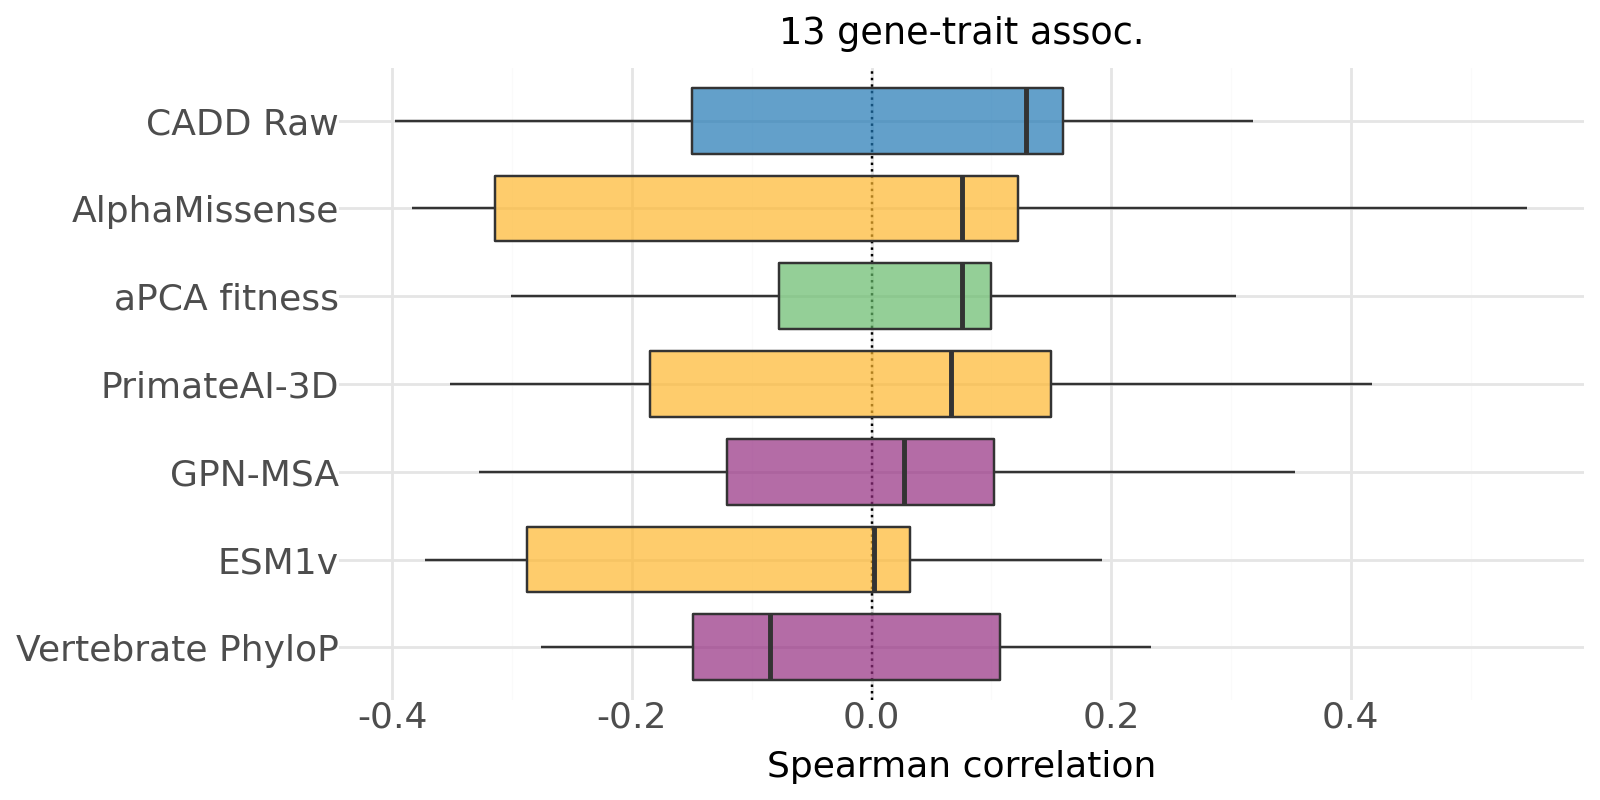

In [13]:
# Compute pairwise Wilcoxon tests between adjacent boxes and add asterisks
from scipy.stats import wilcoxon

plotting_col = 'corr_beta'
dashed_line_value = 1 if 'rescaled' in plotting_col else 0

# Calculate medians and get ordering
corr_pl = (
    filt_corr_df
    .drop_nans()
    .with_columns(
        median_corr_beta = pl.col(plotting_col).median().over("annotation")
    )
)

ordered_labels = (
    corr_pl
    .sort("median_corr_beta", descending=False)
    .select("label")
    .unique(maintain_order=True)
    .to_series()
)

# Get ordered annotations (not labels)
ordered_annos = (
    corr_pl
    .sort("median_corr_beta", descending=False)
    .select("annotation")
    .unique(maintain_order=True)
    .to_series()
)

corr_pl = corr_pl.with_columns(pl.col("label").cast(pl.Enum(ordered_labels)))
color_dict = dict(corr_pl.select("annotation", "color").unique().iter_rows())

# Compute Wilcoxon tests for adjacent pairs (in plot order: bottom to top)
sig_pairs = []
for i in range(len(ordered_annos) - 1):
    anno_below = ordered_annos[i]
    anno_above = ordered_annos[i + 1]
    
    df_below = filt_corr_df.filter(pl.col("annotation") == anno_below).select(["region", "phenotype", "corr_beta"])
    df_above = filt_corr_df.filter(pl.col("annotation") == anno_above).select(["region", "phenotype", "corr_beta"])
    
    merged = df_below.join(df_above, on=["region", "phenotype"], how="inner", suffix="_above")
    
    if merged.height > 0:
        # One-sided test: is anno_above significantly GREATER than anno_below?
        stat, pval = wilcoxon(
            merged["corr_beta_above"].to_numpy(), 
            merged["corr_beta"].to_numpy(), 
            alternative="greater"
        )
        
        if pval < 0.05:
            sig_pairs.append({
                'anno_below': anno_below,
                'anno_above': anno_above,
                'y_pos': i + 0.5,  # Position between the two boxes
                'pval': pval
            })

# Create asterisk annotations
sig_df = pl.DataFrame(sig_pairs) if sig_pairs else None

# Plot with significance asterisks
plot = (
    ggplot(corr_pl, aes(x="label", y=plotting_col, fill="annotation"))
    + geom_hline(aes(yintercept=dashed_line_value), color='black', linetype='dotted')
    + geom_boxplot(alpha=0.7, outlier_shape=None)
    + theme_minimal()
    + scale_fill_manual(values=color_dict)
    + labs(
        x="",
        y="Spearman correlation",
        title=f"{corr_pl[['region', 'phenotype']].unique().shape[0]} gene-trait assoc."
    )
    + coord_flip()
    + theme(
        figure_size=(8, corr_pl['annotation'].n_unique()/2 + 0.5),
        legend_position="none",
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        plot_background=element_rect(fill="white", color="white"),
    )
)

# Add asterisks for significant adjacent pairs
if sig_df is not None and sig_df.height > 0:
    # Get max x value for asterisk placement
    max_x = corr_pl[plotting_col].max() * 1.05
    
    sig_annot = sig_df.with_columns(
        x = pl.lit(max_x),
        label_text = pl.when(pl.col('pval') < 0.001).then(pl.lit('***'))
                      .when(pl.col('pval') < 0.01).then(pl.lit('**'))
                      .when(pl.col('pval') < 0.05).then(pl.lit('*'))
                      .otherwise(pl.lit(''))
    )
    
    plot = plot + geom_text(
        sig_annot, 
        aes(x='x', y='y_pos', label='label_text'),
        size=16,
        color='black',
        ha='left'
    )
    
    print(f"Found {sig_df.height} significant adjacent pairs:")
    for row in sig_df.iter_rows(named=True):
        print(f"  {row['anno_above']} > {row['anno_below']} (p={row['pval']:.4f})")
else:
    print("No significant adjacent pairs found")

plot